In [112]:
import pandas as pd
pd.set_option('display.max_rows', None)
import numpy as np
import seaborn as sns
import statistics
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


In [113]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
od = OrdinalEncoder()
scaler = MinMaxScaler()
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [114]:
test_df['Age'].value_counts()


Age
21.00    17
24.00    17
22.00    16
30.00    15
18.00    13
27.00    12
26.00    12
25.00    11
23.00    11
29.00    10
45.00     9
36.00     9
20.00     8
17.00     7
28.00     7
31.00     6
39.00     6
33.00     6
32.00     6
55.00     6
50.00     5
48.00     5
41.00     5
47.00     5
42.00     5
40.00     5
35.00     5
43.00     4
19.00     4
60.00     3
37.00     3
46.00     3
53.00     3
49.00     3
6.00      3
64.00     3
38.00     3
13.00     3
57.00     3
18.50     3
1.00      3
8.00      2
12.00     2
54.00     2
61.00     2
10.00     2
14.00     2
16.00     2
2.00      2
9.00      2
63.00     2
32.50     2
59.00     1
0.17      1
58.00     1
3.00      1
44.00     1
5.00      1
0.83      1
0.75      1
14.50     1
36.50     1
51.00     1
0.92      1
34.50     1
67.00     1
40.50     1
0.33      1
11.50     1
34.00     1
15.00     1
7.00      1
60.50     1
26.50     1
76.00     1
28.50     1
22.50     1
62.00     1
38.50     1
Name: count, dtype: int64

In [115]:
train_df = train_df.drop(['Cabin', 'Name'], axis=1)
test_df = test_df.drop(['Cabin', 'Name'], axis=1)



In [116]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].mode() [0]) 
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])



test_df['Age'] = test_df['Age'].fillna(test_df['Age'].mean())
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode() [0])

test_df['Fare'] = test_df['Fare'].fillna(0)

test_df['Age'].mode()

0    30.27259
Name: Age, dtype: float64

In [117]:
train_df['Sex'] = od.fit_transform(train_df[['Sex']])
train_df['Embarked'] = od.fit_transform(train_df[['Embarked']])
train_df['Embarked'] = train_df['Embarked'].astype(int)
train_df['Age'] = train_df['Age'].astype(int)


test_df['Embarked'] = od.fit_transform(test_df[['Embarked']])
test_df['Embarked'] = test_df['Embarked'].astype(int)
test_df['Sex'] = od.fit_transform(test_df[['Sex']])
test_df['Sex'] = test_df['Sex'].astype(int)
test_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,1,34.5,0,0,330911,7.8292,1
1,893,3,0,47.0,1,0,363272,7.0000,2
2,894,2,1,62.0,0,0,240276,9.6875,1
3,895,3,1,27.0,0,0,315154,8.6625,2
4,896,3,0,22.0,1,1,3101298,12.2875,2


In [118]:
train_df = train_df.drop(['PassengerId', 'Ticket'], axis=1) 
test_df = test_df.drop(['Ticket'], axis=1)

In [119]:
train_df['Age'] = scaler.fit_transform(train_df[['Age']])
train_df['Fare'] = np.log1p(train_df['Fare'])

test_df['Age'] = scaler.fit_transform(test_df[['Age']])
test_df['Fare'] = np.log1p(test_df['Fare'])

test_df.head(30)


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,1,0.452723,0,0,2.178064,1
1,893,3,0,0.617566,1,0,2.079442,2
2,894,2,1,0.815377,0,0,2.369075,1
3,895,3,1,0.353818,0,0,2.268252,2
4,896,3,0,0.287881,1,1,2.586824,2
5,897,3,1,0.182382,0,0,2.324836,2
6,898,3,0,0.393380,0,0,2.155152,1
7,899,2,1,0.340630,1,1,3.401197,2
8,900,3,0,0.235131,0,0,2.107689,0
9,901,3,1,0.274693,2,0,3.224858,2


<Axes: >

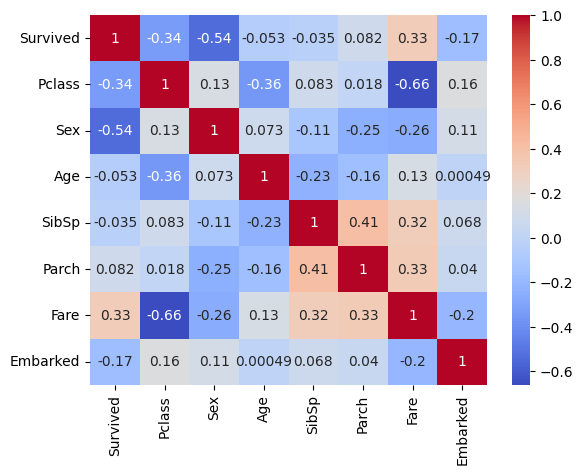

In [120]:
df_corr = train_df.corr()
sns.heatmap(df_corr, cmap='coolwarm', annot=True)

In [121]:
X= train_df.drop(['Survived'], axis=1)

y= train_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=15)

In [122]:
# Dicionários de parâmetros

modelos = {
    'logistic': {
        'model': LogisticRegression(solver='liblinear', multi_class='auto'),
        'params': {
            'C': [1, 5, 10]
        }},
    
    'svm': {
        'model': SVC(gamma='auto', probability=True),
        'params': {
            'C': [1, 10, 20],
            'kernel': ['rbf', 'linear']
        }},
    'knn': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9]
        }
    },
    
    'random forest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [1, 10, 20],
            'max_depth': [3, 4, 5, 6, 7, 8],
            'criterion': ['gini', 'entropy', 'log_loss']
        }
    },
    
    'decision tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [3, 4, 5]
            
        }
    },
    
    'xgb': {
        'model': GradientBoostingClassifier(),
        'params': {
            'loss': ['log_loss'],
            'learning_rate': [0.001, 0.01, 0.1, 1],
            'n_estimators': [50, 100, 150],
            'min_samples_split': [2, 5, 10],
            'max_depth': [3, 4, 5]
        }
    }
    
    }








In [125]:
resultado = []

mm = {}

for model_name, mp in modelos.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    mm[model_name] = clf.best_estimator_
    y_pred = mm[model_name].predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultado.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'accuracy_test': acc,
        'best_params': clf.best_params_
    })


C:\Users\Pichau\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Pichau\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Pichau\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ver

In [128]:
df = pd.DataFrame(resultado, columns=['model', 'best_score', 'accuracy_test', 'best_params'])
df

,model,best_score,accuracy_test,best_params
0,logistic,0.792091,0.798883,{'C': 5}
1,svm,0.808953,0.798883,"{'C': 1, 'kernel': 'rbf'}"
2,knn,0.796267,0.776536,{'n_neighbors': 7}
3,random forest,0.832788,0.837989,"{'criterion': 'gini', 'max_depth': 8, 'n_estim..."
4,decision tree,0.820211,0.798883,"{'criterion': 'entropy', 'max_depth': 3}"
5,xgb,0.830040,0.843575,"{'learning_rate': 0.1, 'loss': 'log_loss', 'ma..."


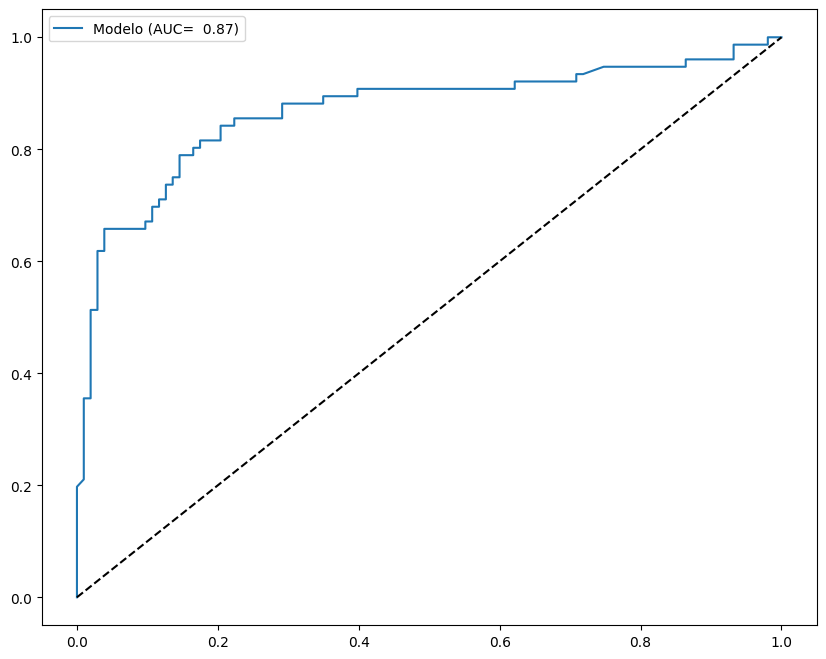

In [ ]:
plt.figure(figsize=(10, 8))

probs = mm.predict_proba(X_test)[:,1]

fp, vp, thresholds = roc_curve(y_test, probs)

valor_auc = auc(fp,vp)

plt.plot(fp, vp, label=f'Modelo (AUC= {valor_auc: .2f})')
plt.plot([0,1], [0,1], 'k--')
plt.legend()


In [132]:
submission_xgb = test_df.drop(['PassengerId'], axis=1)

submission_xgb = mm['xgb'].predict(submission_xgb)

submission_xgb = pd.DataFrame({'PassengerId': test_df['PassengerId'], 'Survived': submission_xgb})

submission_rf = test_df.drop(['PassengerId'], axis=1)

submission_rf = mm['random forest'].predict(submission_rf)

submission_rf = pd.DataFrame({'PassengerId': test_df['PassengerId'], 'Survived': submission_rf})



In [130]:
submission_xgb.to_csv('subsmissao_xgb2.csv', index=False)

In [133]:
submission_rf.to_csv('submissao_rf.csv', index=False)